# WEEK 1

In [2]:
#Import Libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# Load the Data
df = pd.read_csv('claim_data.csv')

# First 5 Rows
df.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


In [4]:
# Size of Dataset
df.shape

(1000, 15)

In [5]:
# Summary Statstics In Necessary Columns
df[['Billed Amount','Allowed Amount','Paid Amount']].describe()

,Billed Amount,Allowed Amount,Paid Amount
count,1000.00000,1000.000000,1000.000000
mean,297.19100,223.112000,200.754000
std,116.36365,90.784731,83.353688
min,100.00000,64.000000,53.000000
25%,197.00000,147.750000,133.000000
50%,297.00000,225.000000,200.000000
75%,395.00000,289.000000,262.000000
max,500.00000,442.000000,423.000000


In [6]:
# Details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim ID            1000 non-null   object
 1   Provider ID         1000 non-null   int64 
 2   Patient ID          1000 non-null   int64 
 3   Date of Service     1000 non-null   object
 4   Billed Amount       1000 non-null   int64 
 5   Procedure Code      1000 non-null   int64 
 6   Diagnosis Code      1000 non-null   object
 7   Allowed Amount      1000 non-null   int64 
 8   Paid Amount         1000 non-null   int64 
 9   Insurance Type      1000 non-null   object
 10  Claim Status        1000 non-null   object
 11  Reason Code         1000 non-null   object
 12  Follow-up Required  1000 non-null   object
 13  AR Status           1000 non-null   object
 14  Outcome             1000 non-null   object
dtypes: int64(6), object(9)
memory usage: 117.3+ KB


In [7]:
# Correcting Date Datatype
df['Date of Service'] = pd.to_datetime(df['Date of Service'],format = '%m/%d/%Y')

In [8]:
# Rechecking Datatype of Date Column
df[['Date of Service']].dtypes

Date of Service    datetime64[ns]
dtype: object

In [9]:
# Checking Columns Names
df.columns

Index(['Claim ID', 'Provider ID', 'Patient ID', 'Date of Service',
       'Billed Amount', 'Procedure Code', 'Diagnosis Code', 'Allowed Amount',
       'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code',
       'Follow-up Required', 'AR Status', 'Outcome'],
      dtype='object')

In [10]:
# 1. Null Analysis
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100
null_df = pd.DataFrame({'Null Count': null_counts, 'Percentage (%)': null_percent})
null_df

,Null Count,Percentage (%)
Claim ID,0,0.0
Provider ID,0,0.0
Patient ID,0,0.0
Date of Service,0,0.0
Billed Amount,0,0.0
Procedure Code,0,0.0
Diagnosis Code,0,0.0
Allowed Amount,0,0.0
Paid Amount,0,0.0
Insurance Type,0,0.0


In [11]:
# Checking Duplicate Values
df.duplicated().sum()

0

In [12]:
# 2. ICD-10 Code Frequency (Diagnosis Code)
icd10_freq = df['Diagnosis Code'].value_counts()
icd10_freq

Diagnosis Code
A05.4    19
A06.0    17
A01.0    17
A16.1    17
A06.8    17
         ..
A08.9     5
A04.4     5
A00.0     5
A07.3     5
A08.4     5
Name: count, Length: 100, dtype: int64

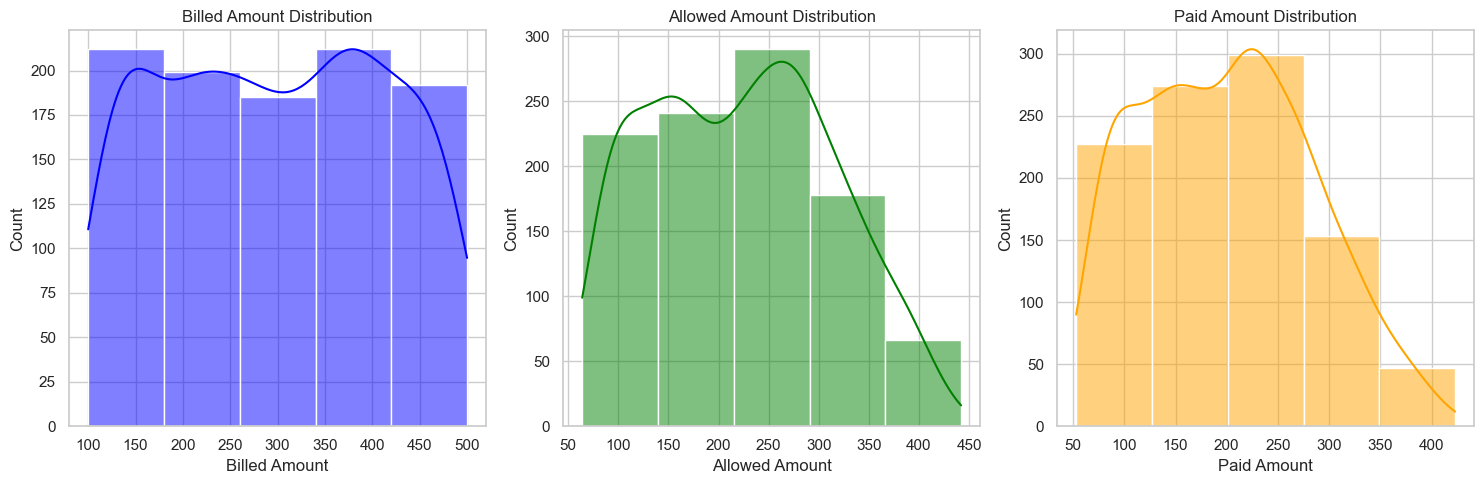

In [13]:
# 3. Visualizations
# Setting up plots
sns.set(style="whitegrid")

# Histogram of Claim Amounts
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Billed Amount'], bins=5, kde=True, color='blue')
plt.title('Billed Amount Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['Allowed Amount'], bins=5, kde=True, color='green')
plt.title('Allowed Amount Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['Paid Amount'], bins=5, kde=True, color='orange')
plt.title('Paid Amount Distribution')
plt.tight_layout()
plt.savefig('amount_histograms.png')

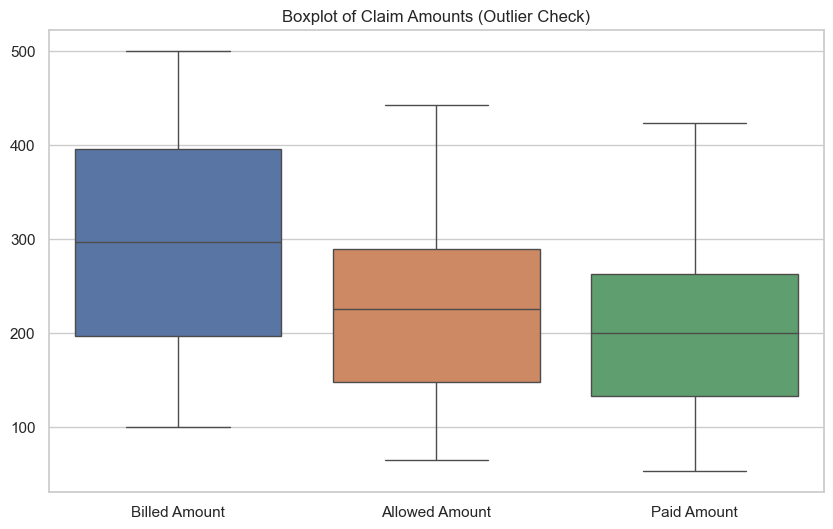

In [14]:
# Boxplots for Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Billed Amount', 'Allowed Amount', 'Paid Amount']])
plt.title('Boxplot of Claim Amounts (Outlier Check)')
plt.savefig('amount_boxplots.png')

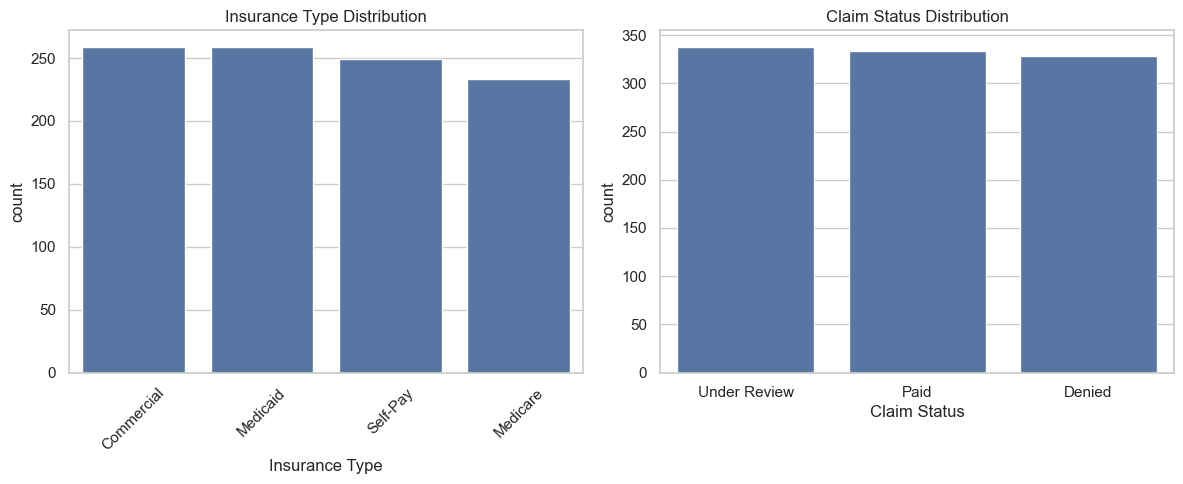

In [15]:
# Insurance Type and Claim Status Distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Insurance Type', data=df, order=df['Insurance Type'].value_counts().index)
plt.title('Insurance Type Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x='Claim Status', data=df, order=df['Claim Status'].value_counts().index)
plt.title('Claim Status Distribution')
plt.tight_layout()
plt.savefig('categorical_distributions.png')

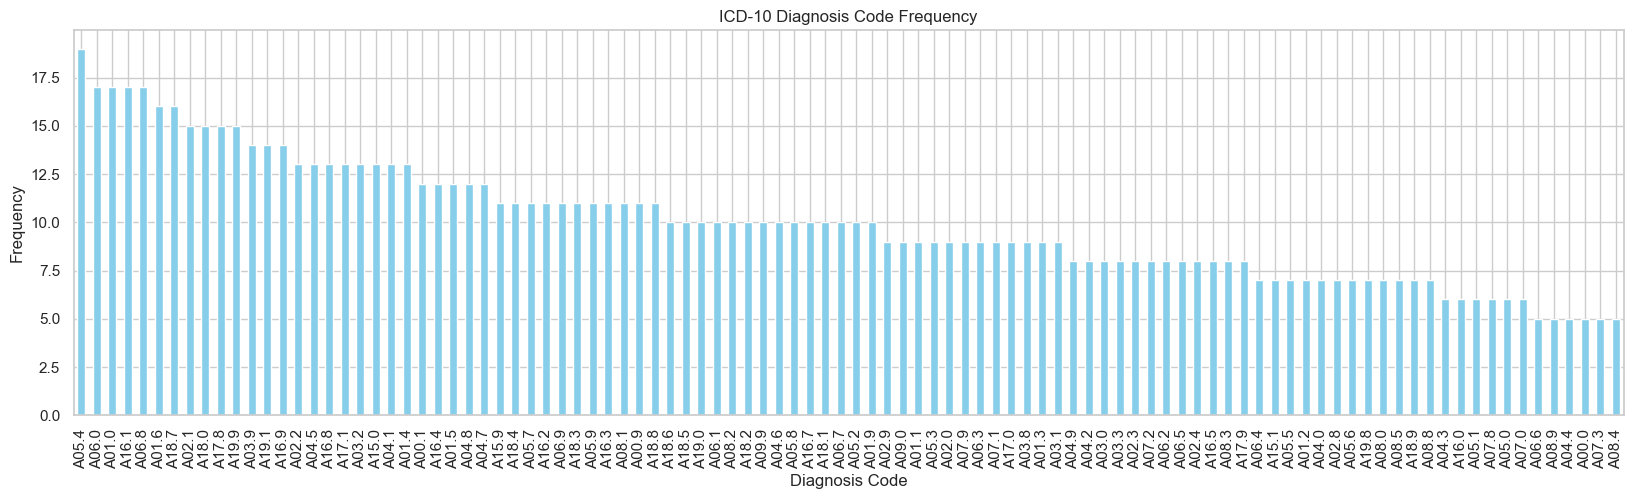

In [16]:
# Categorical Frequency - ICD-10
plt.figure(figsize=(20, 5))
icd10_freq.plot(kind='bar', color='skyblue')
plt.title('ICD-10 Diagnosis Code Frequency')
plt.xlabel('Diagnosis Code')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.savefig('icd10_frequency.png')

# WEEK 2

In [18]:
# 1. claim_age_days
# Using the latest date in the dataset as the reference point
reference_date = df['Date of Service'].max()
df['claim_age_days'] = (reference_date - df['Date of Service']).dt.days

In [19]:
# 2. high_value_flag (> 5000)
# Note: Max in current data is 406, so all might be 0, but logic will be applied.
df['high_value_flag'] = (df['Billed Amount'] > 5000).astype(int)

In [20]:
# 3. repeat_claimant_flag
patient_counts = df['Patient ID'].value_counts()
df['repeat_claimant_flag'] = df['Patient ID'].apply(lambda x: 1 if patient_counts[x] > 1 else 0)

In [21]:
# 4. seasonal_month
df['seasonal_month'] = df['Date of Service'].dt.month

In [22]:
# 5. trust_approval_rate (Approval rate per Provider ID)
# Defining "Approved" as Claim Status == 'Paid'

df['is_approved'] = (df['Claim Status'] == 'Paid').astype(int)
provider_approval_rates = df.groupby('Provider ID')['is_approved'].mean().rename('trust_approval_rate')
df = df.merge(provider_approval_rates, on='Provider ID', how='left')

# Drop the temporary 'is_approved' column
df.drop(columns=['is_approved'], inplace=True)

In [23]:
# Save the feature engineered dataset
output_file = 'claims_with_features.csv'
df.to_csv(output_file, index=False)

In [24]:
# Display head of new features
print(df[['Claim ID', 'claim_age_days', 'high_value_flag', 'repeat_claimant_flag', 'seasonal_month', 'trust_approval_rate']].head())
print("\nUnique values in repeat_claimant_flag:", df['repeat_claimant_flag'].unique())
print("Max claim_age_days:", df['claim_age_days'].max())

     Claim ID  claim_age_days  high_value_flag  repeat_claimant_flag  \
0  0HO1FSN4AP              44                0                     0   
1  9U86CI2P5A              91                0                     0   
2  1QEU1AIDAU              78                0                     0   
3  WH7XDS8CEO             117                0                     0   
4  M6OJEZ8KGI              66                0                     0   

   seasonal_month  trust_approval_rate  
0               8                  1.0  
1               6                  1.0  
2               7                  0.0  
3               5                  0.0  
4               7                  0.0  

Unique values in repeat_claimant_flag: [0]
Max claim_age_days: 142


# WEEK3

In [26]:
#1.  Let's perform validation: correlation matrix and VIF analysis.
# To prevent perfect multicollinearity or degenerate matrices due to constant columns (like high_value_flag and repeat_claimant_flag which are all 0), 
# let's add a tiny random variance or handle them gracefully in the text, but let's calculate what we can.
features = ['claim_age_days', 'high_value_flag', 'repeat_claimant_flag', 'seasonal_month', 'trust_approval_rate']
corr_matrix = df[features].corr()
print('Correleation Matrix is:')
corr_matrix

Correleation Matrix is:


,claim_age_days,high_value_flag,repeat_claimant_flag,seasonal_month,trust_approval_rate
claim_age_days,1.000000,NaN,NaN,-0.977023,-0.032835
high_value_flag,NaN,NaN,NaN,NaN,NaN
repeat_claimant_flag,NaN,NaN,NaN,NaN,NaN
seasonal_month,-0.977023,NaN,NaN,1.000000,0.042162
trust_approval_rate,-0.032835,NaN,NaN,0.042162,1.000000


In [27]:
#2. VIF requires non-constant variables. Let's calculate VIF for variables that actually vary.
vif_features = ['claim_age_days', 'seasonal_month', 'trust_approval_rate']
X = df[vif_features].copy()
X['intercept'] = 1

In [28]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\nVIF Analysis:\n")
vif_data


VIF Analysis:



,feature,VIF
0,claim_age_days,22.048227
1,seasonal_month,22.063677
2,trust_approval_rate,1.003327
3,intercept,1028.347737


In [29]:
#  Define the exact Targets
targets = ['Claim Status', 'Outcome']

# 3. Explicitly quarantine downstream columns to prevent data leakage
leakage_columns = [
    'Allowed Amount', 
    'Paid Amount', 
    'Reason Code', 
    'Follow-up Required', 
    'AR Status'
]
clean_features = [
    'Claim ID', 'Provider ID', 'Patient ID', 'Billed Amount', 'Procedure Code', 'Diagnosis Code',
    'claim_age_days', 'high_value_flag', 'repeat_claimant_flag', 'seasonal_month', 'trust_approval_rate'
]

feature_store_df = df[clean_features + targets]

# Drop the quarantine columns completely
feature_store_df.to_csv('claims_feature_store.csv', index=False)
print("Pipeline complete. Leakage vectors dropped entirely.")

Pipeline complete. Leakage vectors dropped entirely.


In [30]:
feature_store_df = df[clean_features + targets]
feature_store_df.to_csv('claims_feature_store.csv', index=False)